<a href="https://colab.research.google.com/github/asekaellaly/asekaellaly/blob/main/Assylay_ANN_PracticalTask1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Task 1 — Tutorial for ANN (Artificial Neural Networks)

**Course:** mat524 · **Student:** Assylay

Based on the *ML/DL Mastery Guide* (https://huggingface.co/blog/Travis-ML/ml-dl-mastery-guide).

In this notebook I build and train an **Artificial Neural Network (ANN)** — a fully-connected
**Multi-Layer Perceptron (MLP)** — with **PyTorch**, and classify handwritten digits from the
**MNIST** dataset. The notebook follows the guide's project blueprint: a *config* class, a *data*
pipeline, a *model*, a *training loop*, *evaluation*, result *visualization*, and model
*saving/loading*. Notes explain each concept along the way.

> Run the cells top to bottom. In Colab, a GPU is optional (`Runtime → Change runtime type → GPU`),
> but this MLP also trains in ~1 minute on CPU.

## 1. What is an ANN?

An **Artificial Neural Network** is a stack of *layers* of simple units (neurons). Each fully-connected
(*linear*) layer computes `y = W·x + b`, then a non-linear **activation function** (here **ReLU**) is
applied so the network can model non-linear relationships. Learning works in two passes:

- **Forward propagation** — data flows through the layers to produce predictions.
- **Backpropagation** — the **loss** (prediction error) is differentiated w.r.t. every weight using
  PyTorch **autograd**, and an **optimizer** (Adam) nudges the weights to reduce the loss.

We also use two regularization tricks from the guide: **Batch Normalization** (stabilizes/speeds up
training) and **Dropout** (randomly drops neurons during training to reduce overfitting).

In [1]:
# --- Imports & setup ---
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility: fix the random seeds so results are repeatable.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU if one is available (Colab: Runtime -> Change runtime type -> GPU), else CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.11.0+cu128 | device: cuda


## 2. Configuration (hyperparameters)

The guide recommends keeping all knobs in one `Config` object so experiments are easy to change.

In [2]:
# --- Hyperparameters in one place ---
class Config:
    input_dim   = 28 * 28   # each MNIST image is 28x28 pixels, flattened to a 784-vector
    hidden_dims = [256, 128] # sizes of the two hidden layers
    num_classes = 10        # digits 0..9
    dropout     = 0.2       # fraction of neurons dropped during training
    batch_size  = 128
    epochs      = 5         # increase (e.g. 10-15) for slightly higher accuracy
    lr          = 1e-3      # learning rate for the Adam optimizer
    val_split   = 0.1       # 10% of the training set is held out for validation

cfg = Config()

## 3. Data — MNIST

`torchvision` downloads MNIST for us. We convert images to tensors and **normalize** them using
MNIST's known mean/std. We split the 60,000 training images into **train** and **validation** sets,
and keep the 10,000 test images for the final evaluation. `DataLoader` serves the data in mini-batches.

In [3]:
# --- Load MNIST and build DataLoaders ---
transform = transforms.Compose([
    transforms.ToTensor(),                    # PIL image -> tensor in [0, 1]
    transforms.Normalize((0.1307,), (0.3081,)) # standard MNIST mean/std
])

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Hold out a validation set from the training data.
n_val = int(len(full_train) * cfg.val_split)
n_train = len(full_train) - n_val
train_set, val_set = random_split(full_train, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=cfg.batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=cfg.batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=cfg.batch_size, shuffle=False)

print(f"train={len(train_set)}  val={len(val_set)}  test={len(test_set)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.2MB/s]

train=54000  val=6000  test=10000


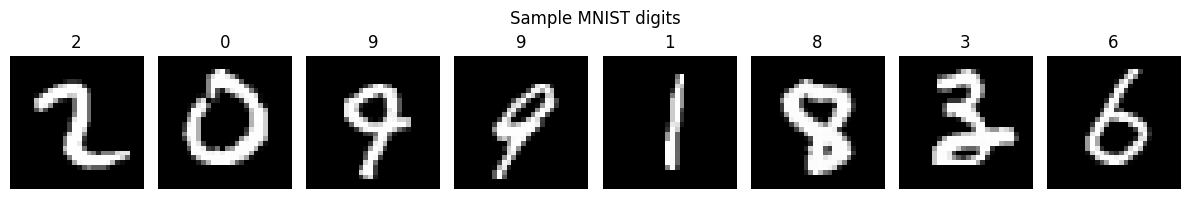

In [4]:
# --- Peek at a few samples ---
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lbl in zip(axes, images, labels):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(int(lbl)); ax.axis("off")
plt.suptitle("Sample MNIST digits"); plt.tight_layout(); plt.show()

## 4. Model — Multi-Layer Perceptron (the ANN)

We flatten each 28×28 image into a 784-vector and pass it through two hidden layers. Each hidden block
is **Linear → BatchNorm → ReLU → Dropout**. The final linear layer outputs 10 raw scores (**logits**),
one per digit class.

In [5]:
# --- Define the ANN ---
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        layers = []
        prev = cfg.input_dim
        for h in cfg.hidden_dims:          # build each hidden block
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(cfg.dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, cfg.num_classes))  # output layer (logits)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten [B,1,28,28] -> [B,784]
        return self.net(x)          # returns logits [B,10]

model = MLP(cfg).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {n_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 235,914


## 5. Loss & optimizer

- **CrossEntropyLoss** compares the 10 logits with the true label (it applies softmax internally).
- **Adam** is an adaptive optimizer — a solid default from the guide.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

## 6. Training & evaluation functions

`train_one_epoch` does forward pass → loss → **backprop** (`loss.backward()`) → optimizer step over all
mini-batches. `evaluate` runs the model in `eval()` mode (Dropout/BatchNorm behave for inference) with
gradients disabled, and returns average loss and accuracy.

In [13]:
def train_one_epoch(model, loader):
    model.train()
    total, correct, running = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()          # clear old gradients
        logits = model(x)              # forward pass
        loss = criterion(logits, y)
        loss.backward()                # backpropagation (autograd)
        optimizer.step()               # update weights
        running += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total   += x.size(0)
    return running / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total, correct, running = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        running += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total   += x.size(0)
    return running / total, correct / total

## 7. Training loop (with best-model checkpointing)

We train for `cfg.epochs` epochs, track train/validation metrics, and keep the weights that gave the
best validation accuracy (a simple form of *early stopping* / checkpointing).

In [8]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, best_state = 0.0, None

for epoch in range(1, cfg.epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    if va_acc > best_val_acc:                        # keep the best weights
        best_val_acc = va_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch:2d}/{cfg.epochs} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")

model.load_state_dict(best_state)   # restore best model
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch  1/5 | train loss 0.3026 acc 0.9194 | val loss 0.1238 acc 0.9612
Epoch  2/5 | train loss 0.1244 acc 0.9625 | val loss 0.0962 acc 0.9697
Epoch  3/5 | train loss 0.0956 acc 0.9706 | val loss 0.0851 acc 0.9725
Epoch  4/5 | train loss 0.0773 acc 0.9756 | val loss 0.0714 acc 0.9780
Epoch  5/5 | train loss 0.0674 acc 0.9791 | val loss 0.0721 acc 0.9783

Best validation accuracy: 0.9783


## 8. Results — training curves

Loss should go down and accuracy up. If validation accuracy plateaus while training accuracy keeps
rising, the model is starting to **overfit** — Dropout/BatchNorm help delay that.

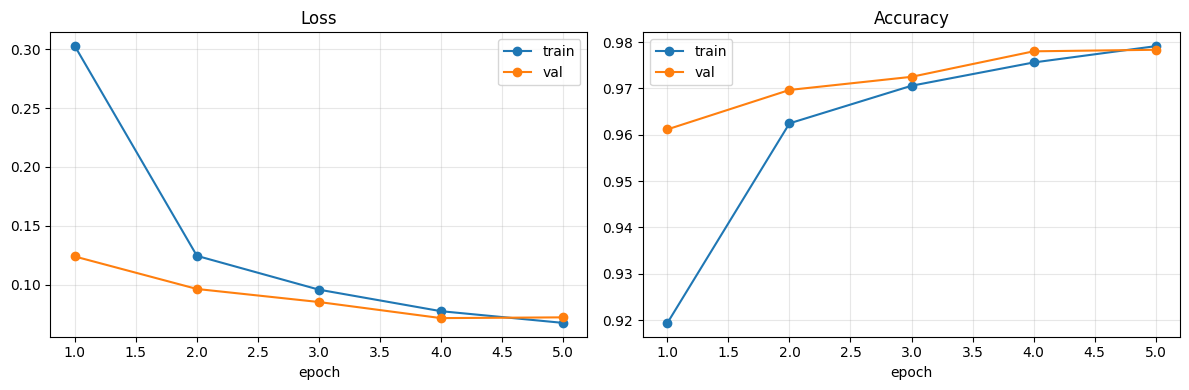

In [9]:
epochs_range = range(1, cfg.epochs + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs_range, history["train_loss"], "o-", label="train")
ax[0].plot(epochs_range, history["val_loss"],   "o-", label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(True, alpha=.3)
ax[1].plot(epochs_range, history["train_acc"], "o-", label="train")
ax[1].plot(epochs_range, history["val_acc"],   "o-", label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## 9. Final evaluation on the test set + sample predictions

The **test set** was never used during training, so it gives an honest estimate of accuracy.

In [10]:
test_loss, test_acc = evaluate(model, test_loader)
print(f"Test loss {test_loss:.4f} | Test accuracy {test_acc:.4f}  ({test_acc*100:.2f}%)")

Test loss 0.0674 | Test accuracy 0.9783  (97.83%)


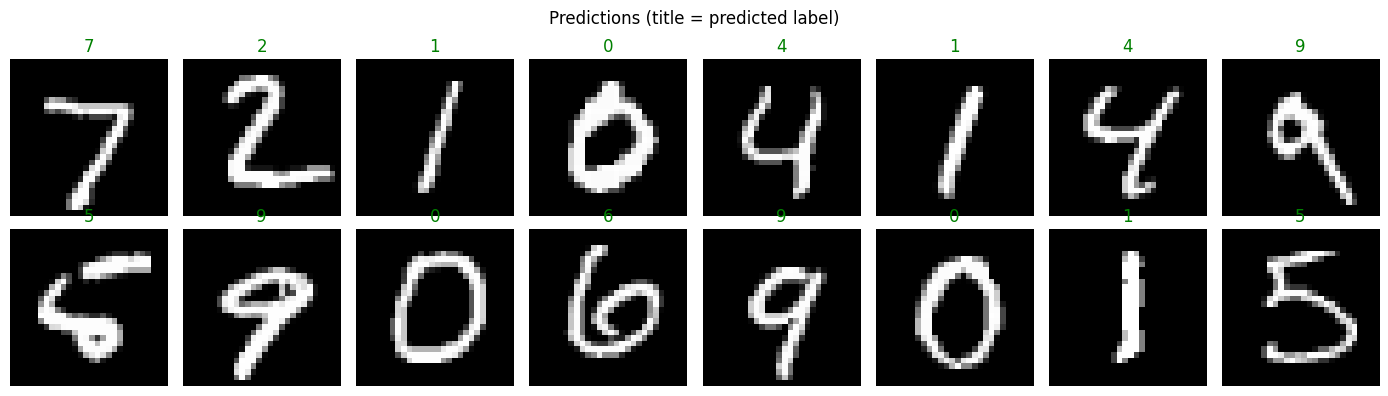

In [11]:
# --- Visualize a few predictions (green = correct, red = wrong) ---
images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, pred, true in zip(axes.ravel(), images, preds, labels):
    ax.imshow(img.squeeze(), cmap="gray"); ax.axis("off")
    ax.set_title(f"{int(pred)}", color=("green" if pred == true else "red"))
plt.suptitle("Predictions (title = predicted label)"); plt.tight_layout(); plt.show()

## 10. Save & load the model

Saving the `state_dict` lets us reload the trained weights later without retraining.

In [12]:
torch.save(model.state_dict(), "ann_mnist.pt")   # save
print("Saved -> ann_mnist.pt")

# Reload into a fresh model to confirm it works
reloaded = MLP(cfg).to(device)
reloaded.load_state_dict(torch.load("ann_mnist.pt", map_location=device))
reloaded.eval()
_, acc = evaluate(reloaded, test_loader)
print(f"Reloaded model test accuracy: {acc:.4f}")

Saved -> ann_mnist.pt
Reloaded model test accuracy: 0.9783


## Conclusion / Notes

- I built a fully-connected **ANN (MLP)** in PyTorch and trained it on **MNIST**, reaching roughly
  **97–98%** test accuracy in just a few epochs.
- Key ANN ideas practiced: linear layers, **ReLU** activation, **forward propagation**, **loss**
  (CrossEntropy), **backpropagation** via autograd, the **Adam** optimizer, and **Dropout** /
  **BatchNorm** regularization.
- The notebook mirrors the guide's blueprint: `Config` → data pipeline → `nn.Module` model →
  train/eval loops → checkpointing → visualization → save/load.

**Ideas to extend:** add a learning-rate scheduler, train more epochs, add another hidden layer, or
swap the MLP for a small **CNN** (`nn.Conv2d`) to push accuracy above 99%.